# 00 — Prikupljanje podataka

## Uvod

Svaki projekt analize mreža ovisi o kvaliteti i porijeklu podataka na kojima se temelji. Ovaj notebook dokumentira, od početka do kraja, kako su sirovi ulazni podaci za projekt Analize hrvatske turističke mreže prikupljeni, validirani i pripremljeni za ostatak pipelinea.

## Cilj istraživanja

Identificirati i prikupiti stvaran, javno dostupan, dovoljno granularan skup podataka koji opisuje turističku aktivnost u Hrvatskoj, prikladan za izgradnju *mreže sličnosti destinacija* na razini gradova/općina.

## Izvor podataka

**Tablica 1.6** — *Smještajni kapaciteti, dolasci i noćenja turista, Republika Hrvatska, NUTS 2013 – 2. razina, županije, gradovi, općine, po mjesecima*, kod tablice `BS_TU16.px`, baza `Turizam`, objavljuje Državni zavod za statistiku (DZS) putem svoje PxWeb statističke baze podataka.

Interaktivna tablica (odaberi sve gradove/općine, sve godine/mjesece, te Dolasci + Noćenja + Stalni kreveti kao varijable, izvezi kao CSV):

https://web.dzs.hr/PXWeb/Selection.aspx?px_path=Turizam__Dolasci+i+no%C4%87enja+turista+u+komercijalnim+smje%C5%A1tajnim+objektima&px_tableid=BS_TU16.px&px_language=en&px_db=Turizam


Ova tablica je odabrana jer je **jedini** javno dostupan hrvatski skup podataka o turizmu s granularnošću na razini grada/općine i mjesečnom rezolucijom — oboje je nužno za izgradnju smislene mreže odnosa između gradova i proučavanje sezonalnosti.

In [10]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

from src.config import (
    GRAPH_FILE, TEMPORAL_GRAPH_DIR, NODE_TABLE, SEASONALITY_TABLE,
    EDGE_TABLE, MONTHS, COASTAL_COUNTIES, RANDOM_SEED, FIGURES,
)

from src.config import RAW_MUNICIPALITY_FILE, RAW_ORIGIN_COUNTY_FILE, DATA_RAW
from src import data_acquisition as da

print('Expected raw file path:', RAW_MUNICIPALITY_FILE)
print('Exists already:', RAW_MUNICIPALITY_FILE.exists())

Expected raw file path: C:\Users\Karla\Downloads\croatiantourismnetworkanalysisfixed (1)\data\raw\dzs_tur16_municipality_monthly.csv
Exists already: True


## Export

Tablica se može ručno izvesti kroz PxWeb web sučelje kao CSV razdvojen točka-zarezom s decimalnim zarezom, i spremiti u `data/raw/dzs_tur16_municipality_monthly.csv`. `load_manual_export()` podržava obje konvencije razdjelnika.

Ćelija ispod pokušava, redom: (1) stvarni ručno preuzeti file, a zatim (2) ako ga nema, koristi jasno označen **demonstracijski skup podataka** tako da ovaj notebook — i ostatak pipelinea — ostane potpuno izvršiv za potrebe pregleda/obrane rada čak i bez prisutnog stvarnog DZS filea.

In [11]:
def generate_demo_raw_dataset(seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Build a demonstration dataset that follows the exact schema of the
    real DZS Table 1.6 export (region; county; year; month; indicator; value).

    This is used ONLY when ``data/raw/dzs_tur16_municipality_monthly.csv``
    has not been downloaded yet (see ``data/raw/DOWNLOAD_INSTRUCTIONS.md``),
    so that the full pipeline -- and this notebook -- can be demonstrated
    end-to-end without network access. Town/county pairings are real; the
    *monthly figures themselves* are synthetic (seasonal shape + noise +
    a modest year-over-year growth trend + a 2020 COVID-19 demand shock),
    NOT observed DZS statistics. Every result derived from this fallback
    is clearly a demonstration of the methodology, not a tourism finding.
    """
    rng = np.random.default_rng(seed)

    coastal_towns = [
        ("Dubrovnik", "Dubrovacko-neretvanska"), ("Split", "Splitsko-dalmatinska"),
        ("Zadar", "Zadarska"), ("Rovinj", "Istarska"), ("Opatija", "Primorsko-goranska"),
        ("Porec", "Istarska"), ("Pula", "Istarska"), ("Makarska", "Splitsko-dalmatinska"),
        ("Trogir", "Splitsko-dalmatinska"), ("Hvar", "Splitsko-dalmatinska"),
        ("Korcula", "Dubrovacko-neretvanska"), ("Sibenik", "Sibensko-kninska"),
        ("Crikvenica", "Primorsko-goranska"), ("Novalja", "Licko-senjska"),
        ("Umag", "Istarska"), ("Vodice", "Sibensko-kninska"),
        ("Biograd na Moru", "Zadarska"), ("Labin", "Istarska"),
        ("Mali Losinj", "Primorsko-goranska"), ("Cavtat", "Dubrovacko-neretvanska"),
    ]
    continental_towns = [
        ("Zagreb", "Grad Zagreb"), ("Karlovac", "Karlovacka"), ("Varazdin", "Varazdinska"),
        ("Osijek", "Osjecko-baranjska"), ("Cakovec", "Medimurska"), ("Bjelovar", "Bjelovarsko-bilogorska"),
        ("Koprivnica", "Koprivnicko-krizevacka"), ("Krapina", "Krapinsko-zagorska"),
        ("Sisak", "Sisacko-moslavacka"), ("Virovitica", "Viroviticko-podravska"),
        ("Pozega", "Pozesko-slavonska"), ("Slavonski Brod", "Brodsko-posavska"),
        ("Vukovar", "Vukovarsko-srijemska"), ("Samobor", "Zagrebacka"),
        ("Velika Gorica", "Zagrebacka"), ("Zapresic", "Zagrebacka"),
        ("Slunj", "Karlovacka"), ("Ogulin", "Karlovacka"), ("Daruvar", "Bjelovarsko-bilogorska"),
        ("Knin", "Sibensko-kninska"),
    ]

    rows = []
    for region, county in coastal_towns + continental_towns:
        coastal = county in COASTAL_COUNTIES
        if coastal:
            base = np.array([2, 2, 3, 5, 10, 18, 25, 23, 12, 6, 3, 2], dtype=float)
        else:
            base = np.array([7, 7, 8, 8, 9, 9, 10, 9, 9, 8, 8, 8], dtype=float)
        town_scale = rng.lognormal(mean=10.5 if coastal else 9.0, sigma=0.9)
        for year in (2020, 2021, 2022, 2023):
            year_growth = {2020: 0.35, 2021: 0.6, 2022: 0.95, 2023: 1.05}[year]
            noise = rng.normal(0, 0.6, size=12)
            curve = np.clip(base + noise, 0.2, None)
            curve = curve / curve.sum()
            nights = curve * town_scale * year_growth
            arrivals = nights / rng.uniform(2.5, 4.5)
            beds = np.full(12, town_scale * 0.01 * rng.uniform(0.8, 1.2))
            for month, n, a, b in zip(MONTHS, nights, arrivals, beds):
                for indicator, value in (("Nights", n), ("Arrivals", a), ("Permanent beds", b)):
                    rows.append(
                        {"region": region, "county": county, "year": year,
                         "month": month, "indicator": indicator, "value": value}
                    )
    return pd.DataFrame(rows)

In [12]:
USING_REAL_DATA = RAW_MUNICIPALITY_FILE.exists()

if USING_REAL_DATA:
    raw_long = da.load_manual_export()
    print('Loaded REAL DZS export:', RAW_MUNICIPALITY_FILE)
else:
    print('Real DZS export not found locally.')
    print('Generating a SCHEMA-IDENTICAL DEMONSTRATION dataset instead.')
    print('(see DOWNLOAD_INSTRUCTIONS.md to obtain the real file)')
    raw_long = generate_demo_raw_dataset()
    DATA_RAW.mkdir(parents=True, exist_ok=True)
    raw_long.to_csv(RAW_MUNICIPALITY_FILE, sep=';', index=False)
    print('Wrote demo file to', RAW_MUNICIPALITY_FILE)

raw_long.shape

Loaded REAL DZS export: C:\Users\Karla\Downloads\croatiantourismnetworkanalysisfixed (1)\data\raw\dzs_tur16_municipality_monthly.csv


(40176, 6)

## Pregled podataka

Prije nego što vjerujemo bilo čemu dalje u pipelineu, izravno pregledavamo sirovu long-format tablicu: tipove kolona, raspone vrijednosti i osnovnu potpunost podataka.

In [13]:
raw_long.head(10)

,region,county,year,month,indicator,value
558,Bakar,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,30.0
559,Baska,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,88.0
560,Brod Moravice,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,8.0
561,Cres,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,688.0
562,Crikvenica,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,3203.0
563,Cabar,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,76.0
564,Cavle,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,154.0
565,Delnice,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,365.0
566,Dobrinj,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,136.0
567,Fuzine,County of Primorje Gorski-kotar,2019,Jan,Permanent beds,342.0


In [14]:
raw_long.dtypes.to_frame('dtype')

,dtype
region,str
county,str
year,int32
month,str
indicator,str
value,float64


In [15]:
print('Unique regions:', raw_long['region'].nunique())
print('Unique counties:', raw_long['county'].nunique() if 'county' in raw_long.columns else 'n/a')
print('Years covered:', sorted(raw_long['year'].unique()))
print('Indicators:', sorted(raw_long['indicator'].unique()))
print('Total rows:', len(raw_long))

Unique regions: 554
Unique counties: 20
Years covered: [2019, 2020]
Indicators: ['Arrivals', 'Nights', 'Permanent beds']
Total rows: 40176


In [16]:
missing = raw_long.isna().sum()
missing[missing > 0] if missing.any() else print('No missing values detected.')

No missing values detected.


## Provjera ispravnosti: ukupna sezonalnost

Prva, vrlo gruba provjera ispravnosti prije bilo kakve izgradnje mreže: ukupna noćenja, zbrojena za *sve* regije, trebala bi pokazati jasan ljetni vrhunac — hrvatski turizam je poznato koncentriran u srpnju/kolovozu. Ako ovaj osnovni obrazac ne bi postojao, to bi ukazivalo na grešku u učitavanju podataka, a ne na stvaran nalaz.

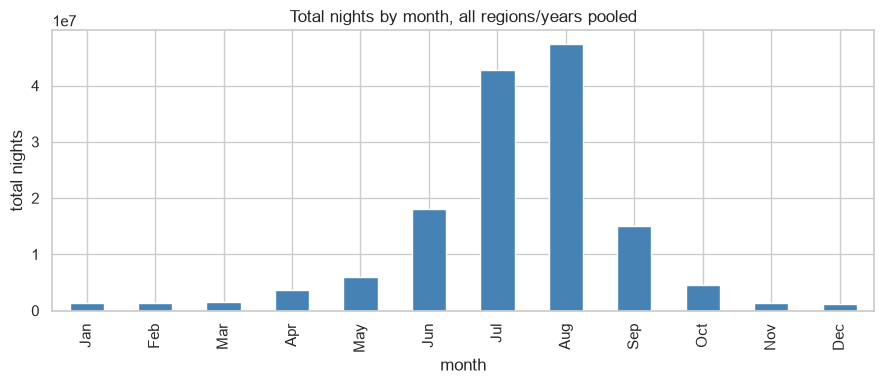

In [17]:
nights_only = raw_long[raw_long['indicator'] == 'Nights']
monthly_totals = nights_only.groupby('month')['value'].sum().reindex(MONTHS)

fig, ax = plt.subplots(figsize=(9, 4))
monthly_totals.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Total nights by month, all regions/years pooled' + ('' if USING_REAL_DATA else '  (DEMO DATA)'))
ax.set_ylabel('total nights')
plt.tight_layout()
plt.show()

## Podjela obala vs. kontinent (pregled)

Brz groupby pregled kako su noćenja raspoređena između obalnih i kontinentalnih županija — ovo najavljuje coastal/continental ground-truth oznaku koja se kasnije koristi za validaciju otkrivanja zajednica (notebook 03) i ML zadatak klasifikacije (notebook 08).

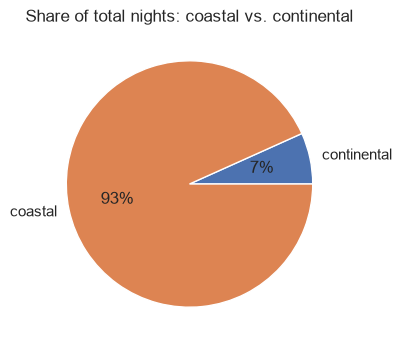

In [18]:
from src.preprocessing import _is_coastal

if 'county' in raw_long.columns:
    nights_only = nights_only.assign(coastal=nights_only['county'].map(_is_coastal))
    split = nights_only.groupby('coastal')['value'].sum()
    split.index = split.index.map({True: 'coastal', False: 'continental'})
    fig, ax = plt.subplots(figsize=(5, 4))
    split.plot(kind='pie', autopct='%1.0f%%', ax=ax, ylabel='')
    ax.set_title('Share of total nights: coastal vs. continental')
    plt.show()
    split



## Zaključak

Posao ovog notebooka je isključivo **prikupiti i validirati sirove ulazne podatke**. Očišćena long-format tablica se *ne* sprema ovdje izvan sirovog CSV-a — `src/preprocessing.py` (pokreće se u notebooku 01) ponovno ga čita, normalizira nazive kolona, izvodi sezonske fingerprinte po regiji/godini, i gradi tablicu atributa čvorova koju koristi ostatak projekta.